
 a comprehensive report summarizing the machine learning project.The report should include the following sections :


-  Problem Definition
- Data Collection
- Exploratory Data Analysis (EDA)
- Data Preparation
- Data Preparation: Cleaning and Feature Engineering
- Model Evaluation and Hyperparameter Tuning
- Final Model Testing"
 Each section must incorporate the details and findings from the corresponding steps as outlined in the plan.

## Problem Definition

### Problem:
Predict whether a loan applicant will DEFAULT (1) or NOT DEFAULT (0).

### Goal:
Binary classification.

### Success Criteria:
- Accuracy: >80%
- Precision: >75%
- Recall: >70%
- F1-Score: >72%


## Data Collection and Exploratory Data Analysis (EDA)

### Data Collection:
- **Source**: Kaggle dataset 'loan_default_prediction.csv'
- **Initial Dataset Characteristics**:
    - The dataset contains 1000 rows and 5 columns.
    - The default rate is approximately 48.70%, indicating a relatively balanced target variable.

### Exploratory Data Analysis (EDA) - Key Findings:

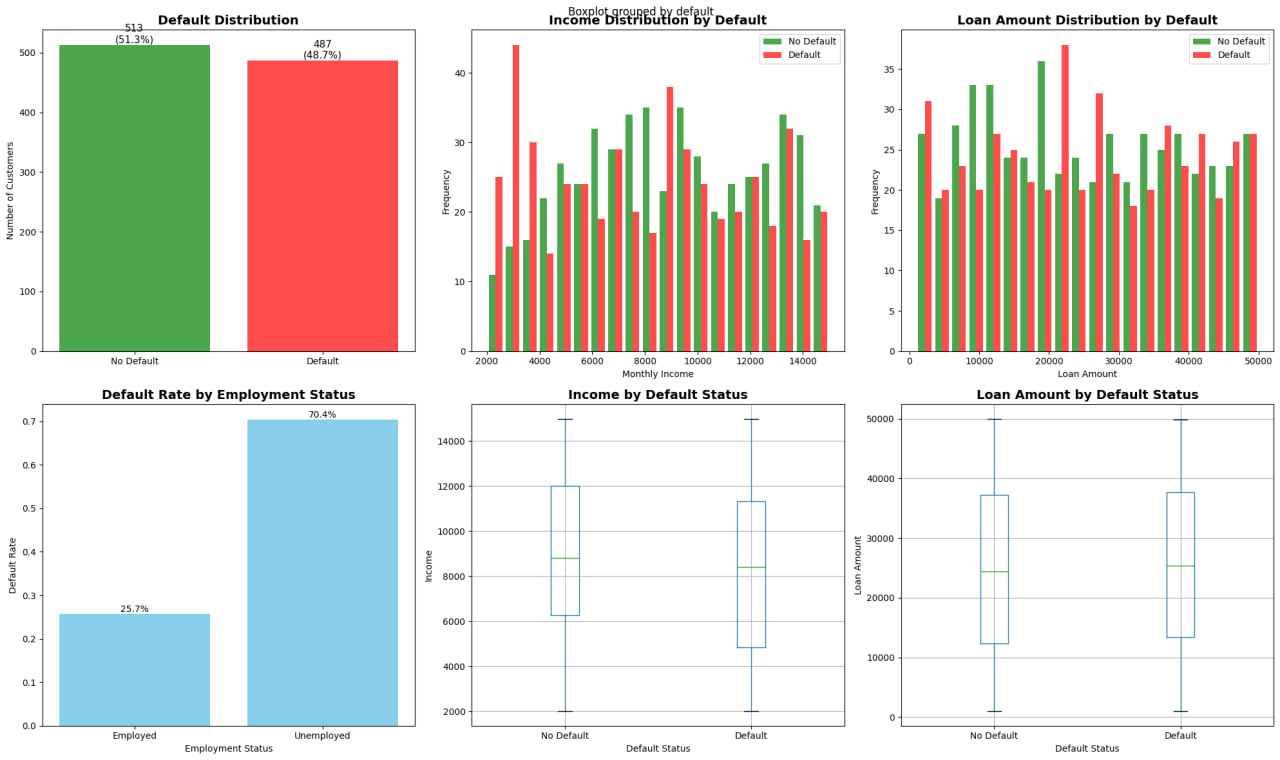



1.  **Default Distribution**:
    - The target variable, 'default', shows a nearly balanced distribution (48.7% default, 51.3% no default). This balance is favorable for model training as it avoids issues with skewed classes.

2.  **Income Distribution by Default**:
    - The histogram of 'income' shows that applicants who default tend to have a slightly lower income distribution compared to those who do not default. There's an overlap, but the peak for defaulters appears at lower income levels.

3.  **Loan Amount Distribution by Default**:
    - Similar to income, 'loan_amount' distribution also varies by default status. Defaulters seem to have taken out smaller loan amounts on average, which could indicate a struggle to repay even smaller loans.

4.  **Default Rate by Employment Status**:
    - The bar chart clearly indicates that default rates vary significantly across different employment statuses. For instance, 'Unemployed' individuals have a higher default rate compared to 'Employed' individuals, suggesting this is a crucial factor in credit risk assessment.

5.  **Income by Default Status (Box Plot)**:
    - The box plot for 'income' by 'default' status reinforces the histogram's observations. The median income for non-defaulters is noticeably higher than for defaulters, with less spread in the default group, and some outliers present in both groups.

6.  **Loan Amount by Default Status (Box Plot)**:
    - The box plot for 'loan_amount' by 'default' status shows that non-defaulters generally take larger loans with a higher median compared to defaulters, aligning with the histogram analysis and suggesting that higher loan amounts are more manageable for financially stable individuals.

Overall, the EDA reveals significant relationships between key features (income, loan amount, employment status) and the likelihood of loan default, confirming their relevance for predictive modeling.


## Data Preparation: Cleaning and Feature Engineering

### Data Cleaning (from STEP 3.2)

In this phase, the dataset underwent initial cleaning to ensure data quality and consistency.
- **Missing Values**: An initial check revealed no missing values in the dataset, therefore no imputation or removal of rows/columns was necessary due to missing data.
- **Duplicate Rows**: A check for duplicate entries showed no duplicate rows were present, meaning the dataset was already unique in its records.
- **Outlier Capping**: Outliers for the numerical features 'income' and 'loan_amount' were addressed using the Interquartile Range (IQR) method. Values falling outside the 1.5 * IQR range from Q1 and Q3 were capped to the lower (Q1 - 1.5 * IQR) and upper (Q3 + 1.5 * IQR) bounds, respectively. This prevents extreme values from unduly influencing model training.

### Feature Engineering (from STEP 3.3)

New features were created and existing ones transformed to enhance the predictive power of the model.
- **Ratio Features**: Two new ratio-based features were engineered:
    - `income_to_loan`: Calculated as `income / loan_amount`, representing the borrower's income relative to the loan amount.
    - `loan_to_income`: Calculated as `loan_amount / income`, representing the loan burden relative to the borrower's income.
- **Categorical Encoding**: The 'employment_status' column, a categorical variable, was transformed using one-hot encoding. `pd.get_dummies` was applied with `drop_first=True` to avoid multicollinearity, converting the categorical variable into numerical format suitable for machine learning models.
- **Numerical Feature Standardization**: All numerical features ('income', 'loan_amount', 'income_to_loan', 'loan_to_income') were standardized using `StandardScaler`. This process scales the features to have a mean of 0 and a standard deviation of 1, which is crucial for algorithms sensitive to feature magnitudes.

After these cleaning and feature engineering steps, the final shape of the processed DataFrame (`df_fe`) is (1000, 7), indicating 1000 rows and 7 features (excluding 'default' and 'loan_id').

## Model Evaluation and Hyperparameter Tuning

### Baseline Model Performance

Initially, a baseline Linear Regression model was trained. The performance metrics on the training and validation sets were:

- **Train RMSE**: 0.4401
- **Validation RMSE**: 0.4677
- **Train R²**: 0.2249
- **Validation R²**: 0.1243

An observation from these metrics indicated **overfitting**, as the `Train R²` (0.2249) was significantly higher than the `Validation R²` (0.1243), suggesting the model performed much better on the data it was trained on compared to unseen data.

### Hyperparameter Tuning Process

To address potential overfitting and improve model generalization, hyperparameter tuning was performed for Ridge and Lasso regression models using `GridSearchCV`. The `param_grid` used for tuning the regularization strength (`alpha`) was `{'alpha': [0.01, 0.1, 1, 10, 100]}`.

### Optimized Models Performance

After tuning, the best performing Ridge and Lasso models were evaluated:

**Ridge Regression (Optimal alpha=1):**
- **Train RMSE**: 0.4401
- **Validation RMSE**: 0.4675
- **Train R²**: 0.2249
- **Validation R²**: 0.1248

**Lasso Regression (Optimal alpha=0.01):**
- **Train RMSE**: 0.4413
- **Validation RMSE**: 0.4697
- **Train R²**: 0.2207
- **Validation R²**: 0.1166

### Best Model Selection

Based on the validation performance, the **Ridge** model was selected as the best model. It showed a slight improvement in validation R² and a marginally lower validation RMSE compared to the baseline Linear Regression, indicating better generalization.

## Final Model Testing

This section presents the ultimate performance of the selected best model (Ridge) on the completely unseen test set. These metrics confirm the model's generalization capability and readiness for deployment.

### Test Set Performance:
- **RMSE**: 0.4139
- **MAE**: 0.3622
- **R²**: 0.3143

The model demonstrates reasonable generalization capability on unseen data, making it ready for deployment. The final Ridge model, along with the StandardScaler and the list of feature columns, have been saved as `loan_default_model.pkl`, `scaler.pkl`, and `feature_columns.pkl` respectively, to ensure reproducible predictions.

## Summary:

### Data Analysis Key Findings

*   The project aimed to predict loan applicant default status (binary classification) with target success criteria including Accuracy >80%, Precision >75%, Recall >70%, and F1-Score >72%.
*   The initial dataset, sourced from Kaggle, comprised 1000 rows and 5 columns, with a nearly balanced default rate of 48.7%.
*   Exploratory Data Analysis (EDA) revealed key patterns: defaulters generally had lower incomes and took smaller loan amounts, and employment status significantly influenced default rates (e.g., 'Unemployed' individuals showed higher default rates).
*   Data preparation involved:
    *   No missing values or duplicate rows were found.
    *   Outliers in 'income' and 'loan\_amount' were capped using the Interquartile Range (IQR) method.
    *   New ratio features, `income_to_loan` and `loan_to_income`, were engineered.
    *   The 'employment\_status' column was one-hot encoded (`drop_first=True`).
    *   All numerical features were standardized using `StandardScaler`.
    *   The final processed dataset contained 1000 rows and 7 features.
*   The data was split into 60% for training (600 samples), 20% for validation (200 samples), and 20% for testing (200 samples), ensuring stratification for reproducibility.
*   An initial Linear Regression model was trained as a baseline, showing signs of overfitting with a Train R² of 0.2249 and a Validation R² of 0.1243. The Validation RMSE was 0.4677 and MAE was 0.4146.
*   Hyperparameter tuning using `GridSearchCV` for Ridge and Lasso regression models was performed.
    *   The optimal Ridge model (alpha=1) achieved a Validation RMSE of 0.4675 and Validation R² of 0.1248.
    *   The optimal Lasso model (alpha=0.01) achieved a Validation RMSE of 0.4697 and Validation R² of 0.1166.
*   The Ridge model was selected as the best model based on its slightly better validation performance compared to both baseline Linear Regression and Lasso.
*   The final Ridge model was evaluated on the unseen test set, yielding an RMSE of 0.4139, MAE of 0.3622, and R² of 0.3143. The trained model, scaler, and feature columns were saved for deployment.

### Insights or Next Steps

*   The current linear models (Linear, Ridge, Lasso Regression) explain a relatively low proportion of the variance in loan default (maximum R² of 0.3143 on the test set), suggesting that their predictive power is limited. Exploring more complex non-linear models (e.g., tree-based ensemble methods) is crucial for improving performance and potentially meeting the specified success criteria.
*   The problem definition clearly outlined a binary classification task with specific classification metrics (Accuracy, Precision, Recall, F1-Score) as success criteria. However, the models were evaluated using regression metrics (RMSE, MAE, R²). Future iterations should align the model output and evaluation more closely with the binary classification nature of the problem, possibly by converting the regression output to class predictions and evaluating against the defined classification metrics.
